In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

# подключаем функции fft, fftfreq
from scipy.fft import fft, fftfreq

In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# решение дисперсионного уравнения
# относительно вектора k
def K(Omega, Nu, Alpha):
    if Alpha == 0:
        z = Omega / Nu
    else:
        z = -1 / (2 * Alpha) + np.sqrt((1 / 2 * Alpha) ** 2 + Omega / (Alpha * Nu))
    return z


In [3]:
# Ячейка № 3
# вычисление начальных значений
# действительной и мнимой частей
# волнового пакета в узлах выбранной
# временной сетки
# в момент времени t = 0


# задание параметров
# временной сетки
T_min = 0
T_max = 200
Nt = 2**10

# вычисление координат узлов
# временной сетки
t = np.linspace(T_min, T_max, Nt)

# задание параметров
# начального возмущения
Omega = 0.7
A = 1

# задание скорости движения
# волнового пакета
v = 1

# задание параметра
# дисперсионного соотношения
Alpha = 1.0


# вычисление мгновенных значений
# начального возмущения
# в узлах выбранной временной сетки
z = np.zeros(Nt) + 1j * np.zeros(Nt)
z[:] = A * np.exp(1j * Omega * t[:]) * np.exp(-(((t[:] - 40) / 10) ** 2))


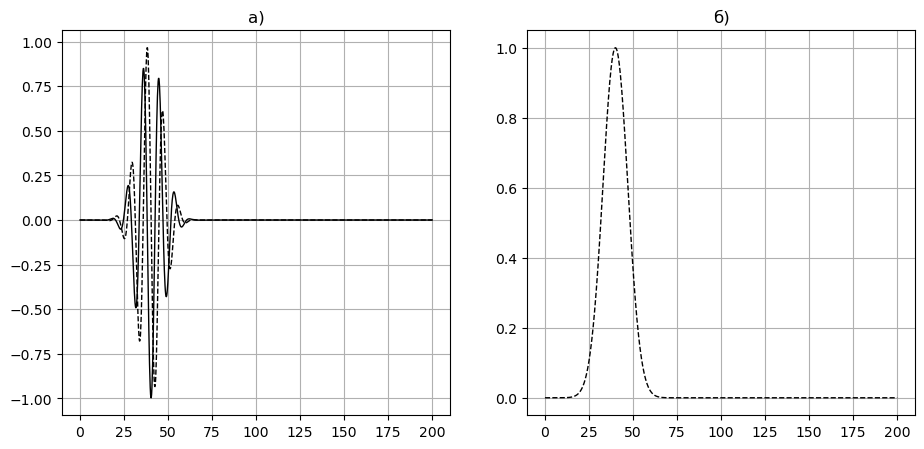

In [4]:
# Ячейка № 4

# визуализация действительной,
# мнимой составляющих и огибающей
# волнового пакета

fig = plt.figure(figsize=(11, 5))

# визуализация действительной и мнимой
# составляющих волнового пакета
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(t, np.real(z), "-k", lw=1)
ax1.plot(t, np.imag(z), "k--", lw=1)
ax1.grid(True)
plt.title("a)")

# визуализация огибающей волнового пакета
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, np.abs(z), "--k", lw=1)
ax2.grid(True)
plt.title("б)")

plt.show()


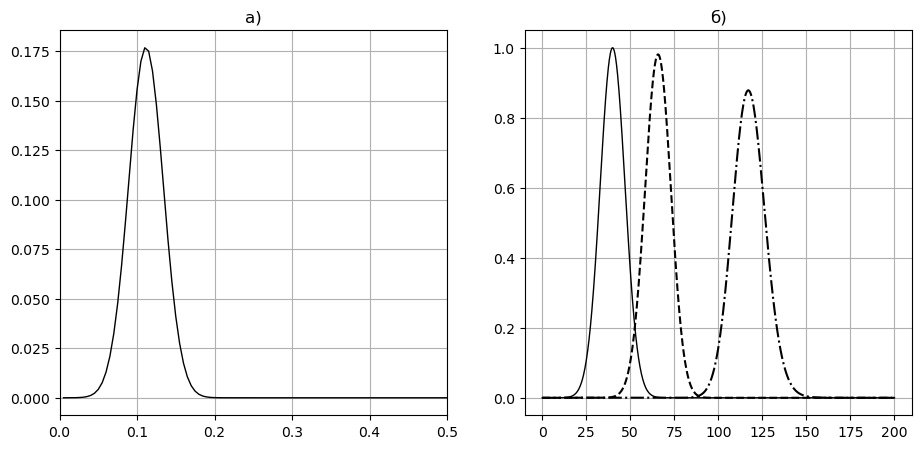

In [5]:
# Ячейка № 5

# вычисление и визуализация
# спектра волнового пакета
# и его огибающих в выбранные
# моменты времени

# вычисление дискретного преобразования Фурье
# начального возмущения по переменной t
s = fft(z)

# нормировка спектра на число отсчетов
# исходной последовательности
s = s / Nt

# вычисляем базовую циклическую частоту
# дикретного преобразования Фурье
Omega = 2 * np.pi / (T_max - T_min)


# задание функции, возвращающей
# значения волнового пакета
# в узлах выбранной координатной сетки
# в соответствие с (9.81)
def WavePacket(s, x, t, Omega, Nt):
    psi = np.zeros(Nt) + 1j * np.zeros(Nt)
    for j in range(Nt):
        su = 0 + 1j * 0
        for n in range(Nt):
            su = su + s[n] * np.exp(
                1j * (Omega * n * t[j] - K(Omega * n, v, Alpha) * x)
            )
        psi[j] = su
    return psi


# визуализация спектра волнового пакета
# в выбранные моменты времени
dt = t[1] - t[0]

# вычисление частот спектральных гармоник
Freq = fftfreq(Nt, dt)

# вычисление значения
# наибольшего номера
# информативной спектральной гармоники
N2 = round((Nt - 1) / 2) - 1

# вычисление значений
# частот информативных гармоник
Freq_R = np.zeros(N2)
for i in range(N2):
    Freq_R[i] = Freq[i + 1]

    # выделение информативной части
    # спектра i-ой моды
    # нормальных колебаний
    s_R1 = np.zeros(N2)
    for j in range(N2):
        s_R1[j] = np.abs(2 * s[j + 1])

fig = plt.figure(figsize=(11, 5))

# визуализация спектра
# начального возмущения
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(Freq_R, s_R1, "-k", lw=1)
ax1.set_xlim([0, 0.5])
ax1.grid(True)
plt.title("a)")

# вычисление значений
# волнового пакета
# в выбранные моменты времени
# в узлах выбранной координатной сетки
x1 = 0
Psi1 = WavePacket(s, x1, t, Omega, Nt)

x2 = 50
Psi2 = WavePacket(s, x2, t, Omega, Nt)

x3 = 150
Psi3 = WavePacket(s, x3, t, Omega, Nt)

# визуализация огибающих
# волнового пакета,
# выбранных точках пространства
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, np.abs(Psi1), "-k", lw=1)
ax2.plot(t, np.abs(Psi2), "k--")
ax2.plot(t, np.abs(Psi3), "k-.")
ax2.grid(True)
plt.title("б)")

plt.show()
